In [ ]:
 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sales = pd.read_csv(r"C:\Users\rhiab\Downloads\supermarket_sales - Sheet1 (1).csv")

In [4]:
sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
Invoice ID                 1000 non-null object
Branch                     1000 non-null object
City                       1000 non-null object
Customer type              1000 non-null object
Gender                     1000 non-null object
Product line               1000 non-null object
Unit price                 1000 non-null float64
Quantity                   1000 non-null int64
Tax 5%                     1000 non-null float64
Total                      1000 non-null float64
Date                       1000 non-null object
Time                       1000 non-null object
Payment                    1000 non-null object
cogs                       1000 non-null float64
gross margin percentage    1000 non-null float64
gross income               1000 non-null float64
Rating                     1000 non-null float64
dtypes: float64(7), int64(1), object(9)
memory usage: 132.9+ KB


By inspection, the 'Date' datatype is an object, we need to change it to datetime

In [5]:
sales['date'] = pd.to_datetime(sales['Date'])


In [6]:
sales['date'].dtype

dtype('<M8[ns]')

In [7]:
type(sales['date'])

pandas.core.series.Series

In [8]:
sales['date'] = pd.to_datetime(sales['date'])

In [7]:
sales['day'] = (sales['date']).dt.day
sales['month'] = (sales['date']).dt.month
sales['year'] = (sales['date']).dt.year

In [8]:
sales['Time'] = pd.to_datetime(sales['Time'])

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\721023929.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['Time'] = pd.to_datetime(sales['Time'])


In [9]:
sales['Hour'] = (sales['Time']).dt.hour    #type(sales['Time'])

Let's see the unique hours of sales in this dataset

In [10]:
sales['Hour'].nunique()  #gives us the number of unique hours 

11

In [ ]:
sales['Hour'].unique()

array([13, 10, 20, 18, 14, 11, 17, 16, 19, 15, 12], dtype=int32)

In [12]:
sales.describe()

,Unit price,Quantity,Tax 5%,Total,Time,cogs,gross margin percentage,gross income,Rating,date,day,month,year,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000,1000.000000,1000.000000,1000.0,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2026-06-21 15:24:41.880000,307.58738,4.761905e+00,15.379369,6.97270,2019-02-14 00:05:45.600000,15.256000,1.993000,2019.0,14.910000
min,10.080000,1.000000,0.508500,10.678500,2026-06-21 10:00:00,10.17000,4.761905e+00,0.508500,4.00000,2019-01-01 00:00:00,1.000000,1.000000,2019.0,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2026-06-21 12:43:00,118.49750,4.761905e+00,5.924875,5.50000,2019-01-24 00:00:00,8.000000,1.000000,2019.0,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2026-06-21 15:19:00,241.76000,4.761905e+00,12.088000,7.00000,2019-02-13 00:00:00,15.000000,2.000000,2019.0,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2026-06-21 18:15:00,448.90500,4.761905e+00,22.445250,8.50000,2019-03-08 00:00:00,23.000000,3.000000,2019.0,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2026-06-21 20:59:00,993.00000,4.761905e+00,49.650000,10.00000,2019-03-30 00:00:00,31.000000,3.000000,2019.0,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858,NaN,8.693563,0.835254,0.0,3.186857


 ### Let's find the number of unique values in columns with object datatype

In [13]:
categorical_columns = [cname for cname in sales.columns if sales[cname].dtype == "object"]

In [14]:
categorical_columns

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Date',
 'Payment']

In [32]:
print("# unique values in Branch: {0}".format(len(sales['Branch'].unique().tolist())))
print("# unique values in City: {0}".format(len(sales['City'].unique().tolist())))
print("# unique values in Customer Type: {0}".format(len(sales['Customer type'].unique().tolist())))
print("# unique values in Gender: {0}".format(len(sales['Gender'].unique().tolist())))
print("# unique values in Product Line: {0}".format(len(sales['Product line'].unique().tolist())))
print("# unique values in Payment: {0}".format(len(sales['Payment'].unique().tolist())))

# unique values in Branch: 3
# unique values in City: 3
# unique values in Customer Type: 2
# unique values in Gender: 2
# unique values in Product Line: 6
# unique values in Payment: 3


C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\3794815732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data =sales,palette="Set3" ,legend = 'False' )


Text(0.5, 1.0, 'Gender_Count')

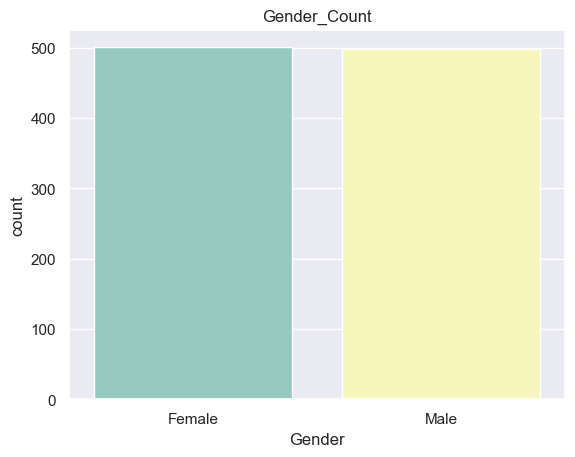

In [ ]:
sns.set(style="darkgrid")       #style the plot background to become a grid
sns.countplot(x="Gender", data =sales,palette="Set3" ,legend = 'False' )
plt.title("Gender_Count")

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\797278377.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Branch", y = "Rating" ,data =sales , palette='Set1')


Text(0.5, 1.0, 'Ratings by Branch')

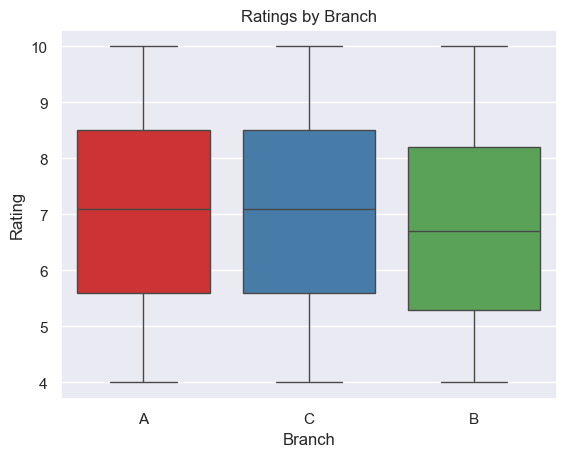

In [23]:
sns.boxplot(x="Branch", y = "Rating" ,data =sales , palette='Set1')
plt.title("Ratings by Branch") 

Branch B has the lowest rating among all the branches

*Sales by the hour in the comapny* Most of the item were sold around 14:00 hrs local time

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\1105619613.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="Hour",  y = 'Quantity',data =sales, palette='Set3')


Text(0.5, 1.0, 'Product Sales per Hour')

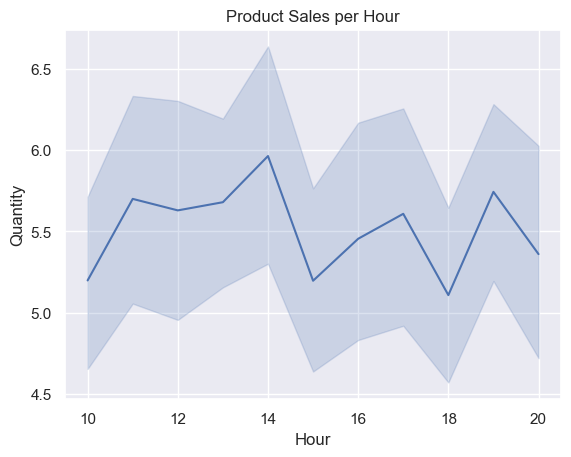

In [25]:
sns.lineplot(x="Hour",  y = 'Quantity',data =sales, palette='Set3')
plt.title("Product Sales per Hour")

Below we can see how each branch's sales quantity looks like by the hour in a monthly fashion 

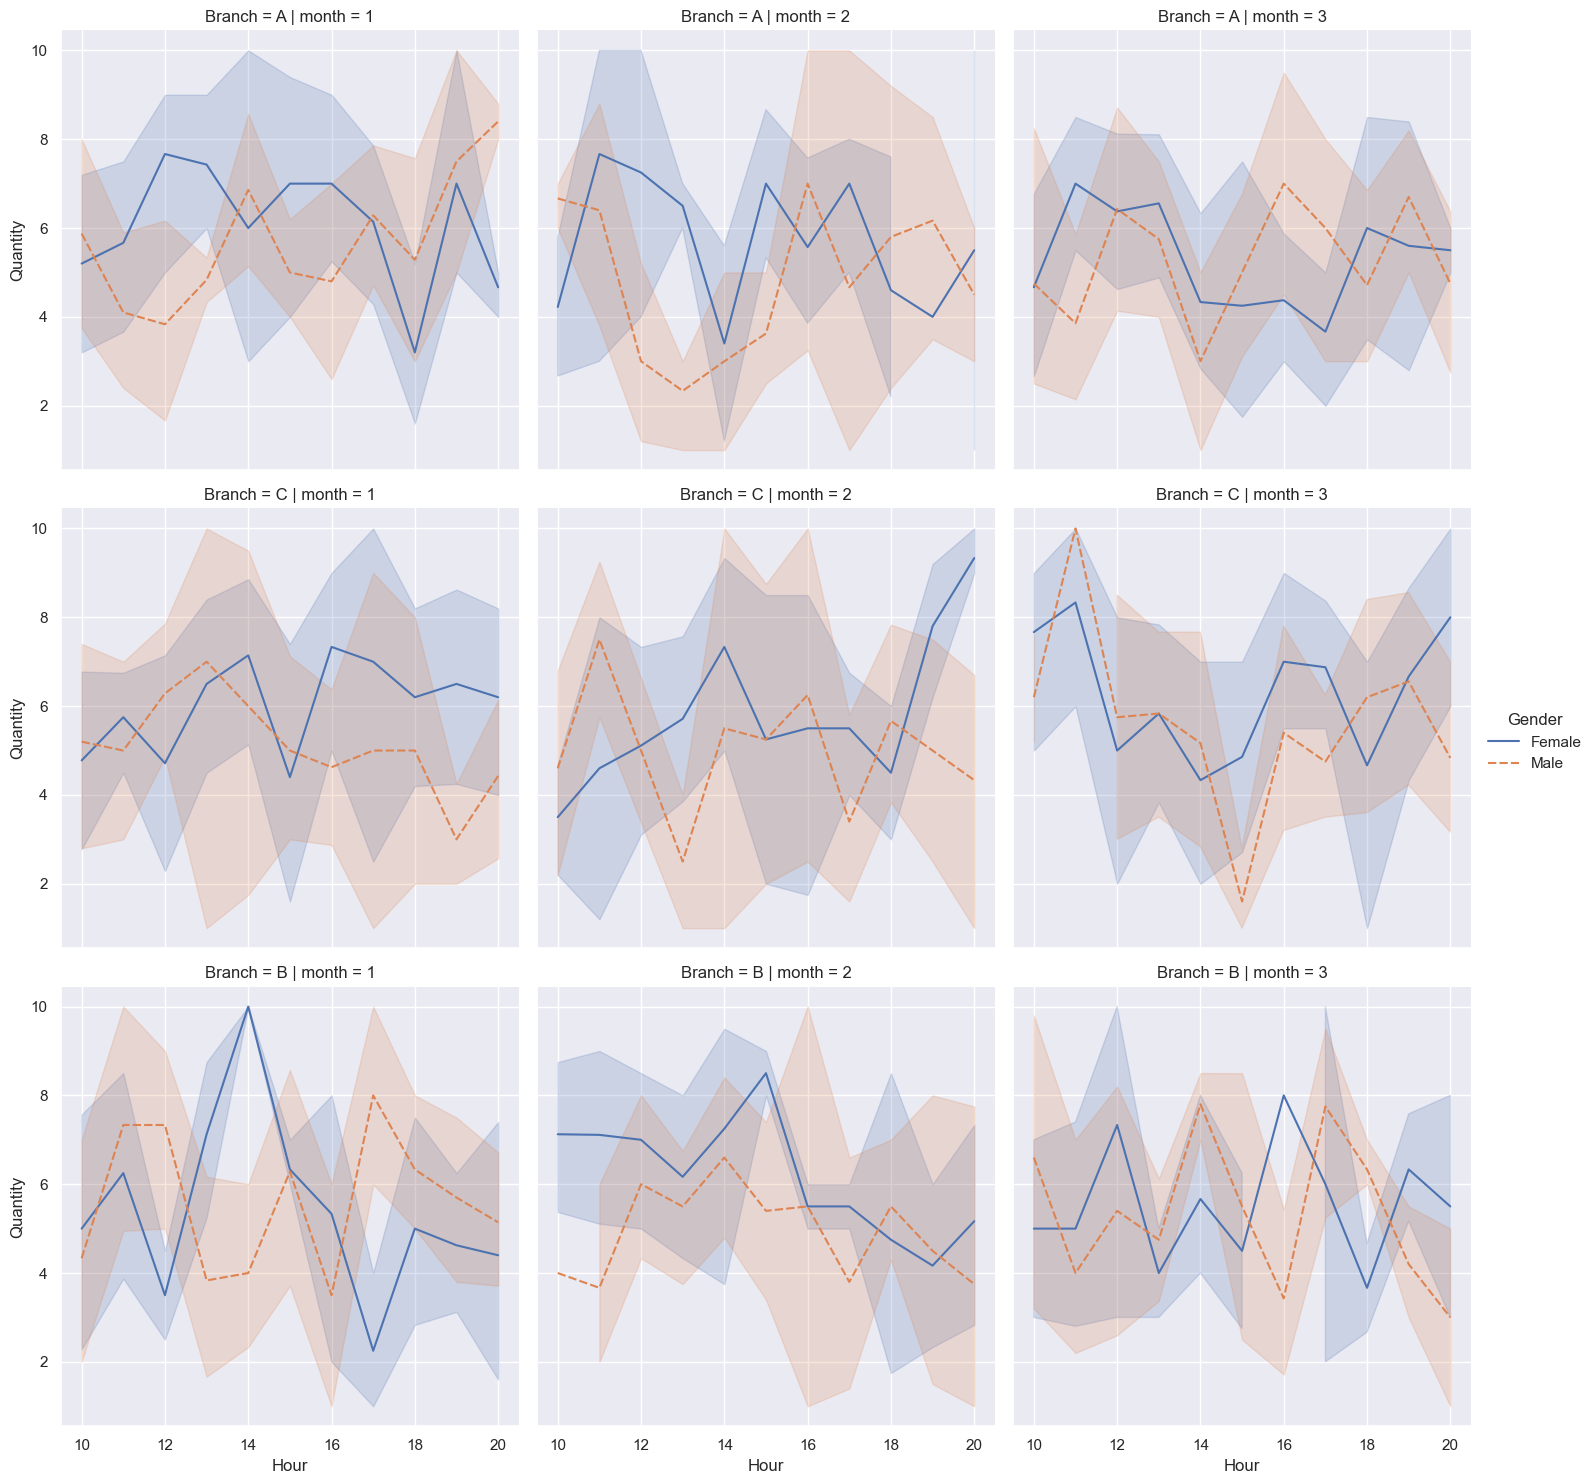

In [52]:
sns.relplot(x="Hour",  y = 'Quantity', col= 'month' , row= 'Branch', kind="line", hue="Gender", style="Gender", data =sales)

 Below we can see each branch's sales by the hour in a monthly fashion 

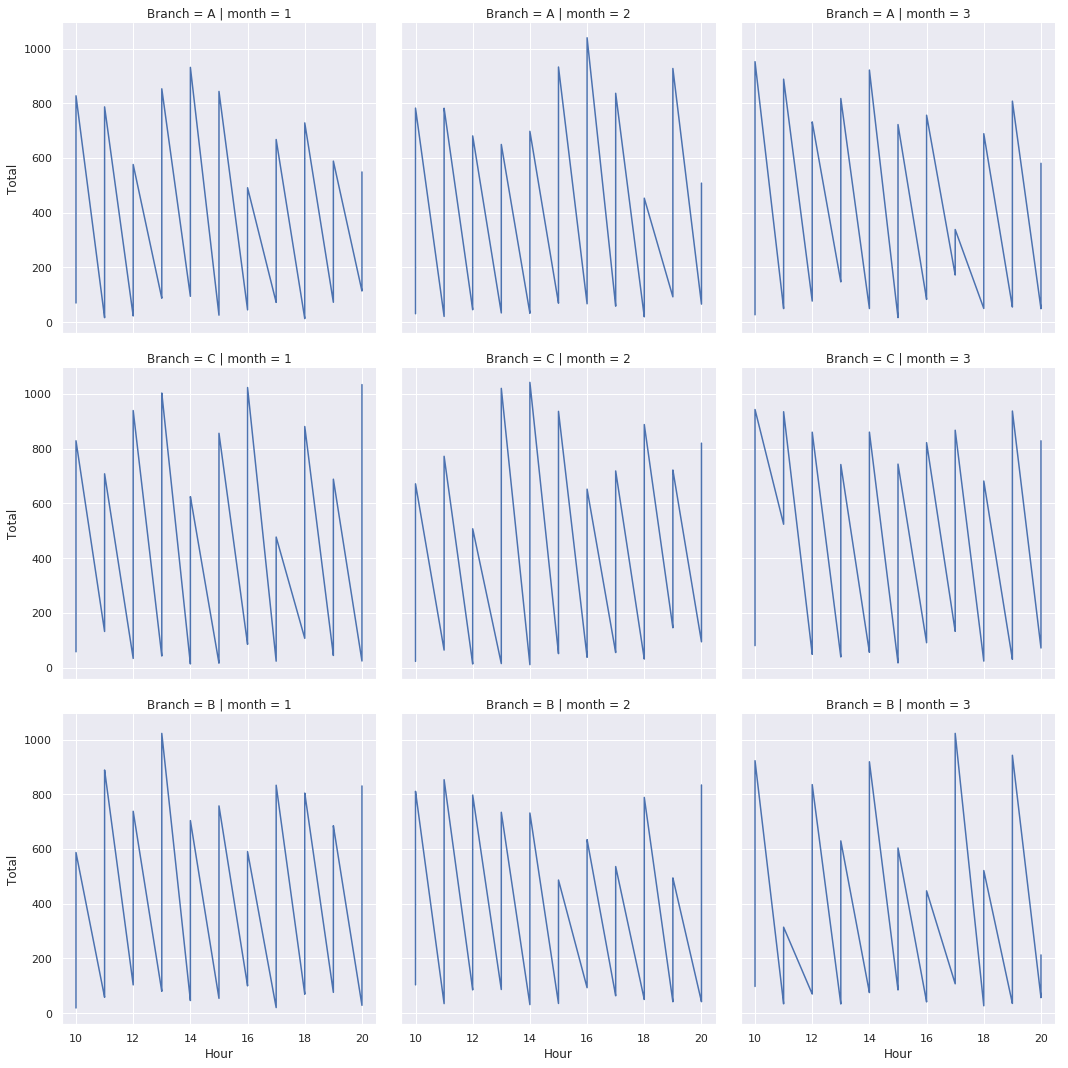

In [ ]:
sns.relplot(x="Hour",  y = 'Total', col= 'month' , row= 'Branch', estimator = None, kind="line", data =sales)

In [27]:
sales['Rating'].unique()

array([ 9.1,  9.6,  7.4,  8.4,  5.3,  4.1,  5.8,  8. ,  7.2,  5.9,  4.5,
        6.8,  7.1,  8.2,  5.7,  4.6,  6.9,  8.6,  4.4,  4.8,  5.1,  9.9,
        6. ,  8.5,  6.7,  7.7,  7.5,  7. ,  4.7,  7.6,  7.9,  6.3,  5.6,
        9.5,  8.1,  6.5,  6.1,  6.6,  5.4,  9.3, 10. ,  6.4,  4.3,  4. ,
        8.7,  9.4,  5.5,  8.3,  7.3,  4.9,  4.2,  9.2,  7.8,  5.2,  9. ,
        8.8,  6.2,  9.8,  9.7,  5. ,  8.9])

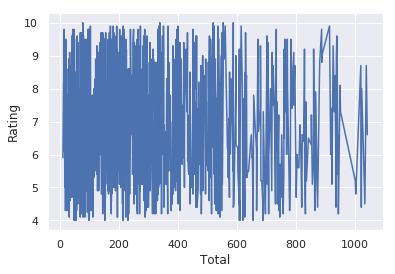

In [24]:
ageDisSpend = sns.lineplot(x="Total", y = "Rating", data =sales)

## Product Analysis

Let's look at the various products' performance.

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\3241145183.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y = 'Product line', x = 'Quantity', data=sales , palette='Set1')


<Axes: xlabel='Quantity', ylabel='Product line'>

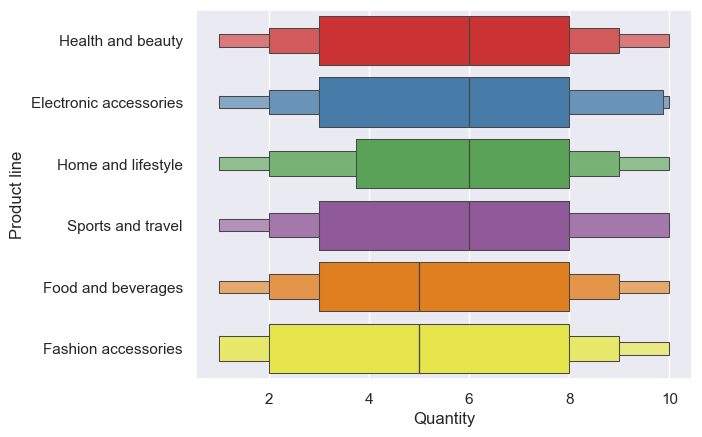

In [29]:
sns.boxenplot(y = 'Product line', x = 'Quantity', data=sales , palette='Set1')

From the above visual, Health and Beauty,Electronic accessories, Homem and lifestyle, Sports and travel have a better average quantity sales that food and beverages as well as Fashion accessories. 

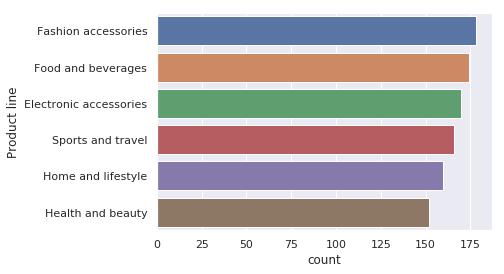

In [26]:
sns.countplot(y = 'Product line', data=sales, order = sales['Product line'].value_counts().index )

From the above image shows the top product line item type sold in the given dataset. Fashion Accessories is the highest while Health and beauty is the lowest

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\268781971.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y = 'Product line', x = 'Total', data=sales , palette='Set3')


<Axes: xlabel='Total', ylabel='Product line'>

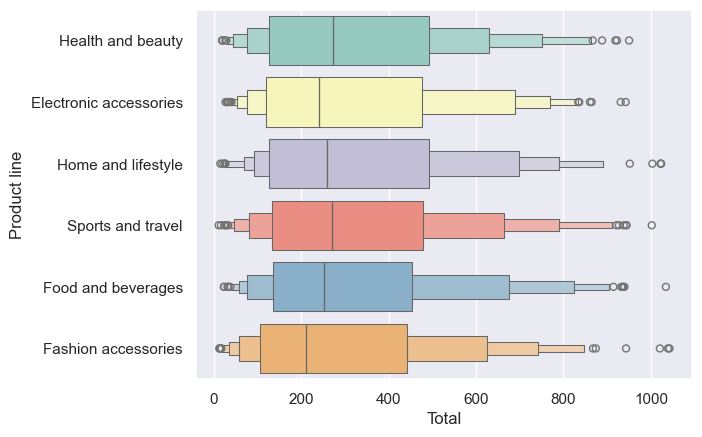

In [34]:
sns.boxenplot(y = 'Product line', x = 'Total', data=sales , palette='Set3')

<Axes: xlabel='Total', ylabel='Product line'>

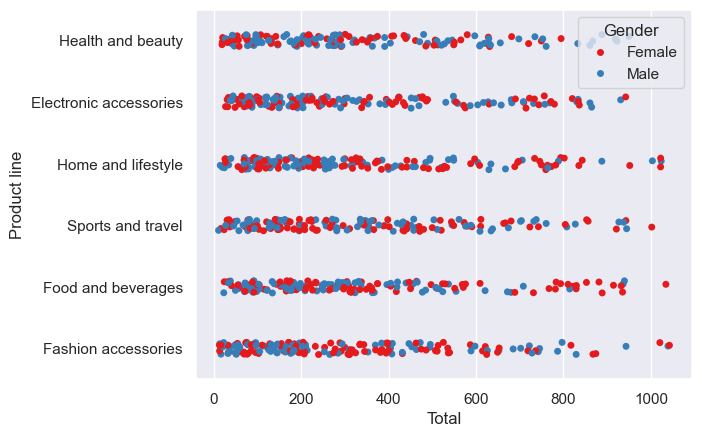

In [35]:
sns.stripplot(y = 'Product line', x = 'Total', hue = 'Gender', data=sales,palette='Set1' )

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\2048202881.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(y = 'Product line', x = 'gross income', data=sales , palette= 'Set2')


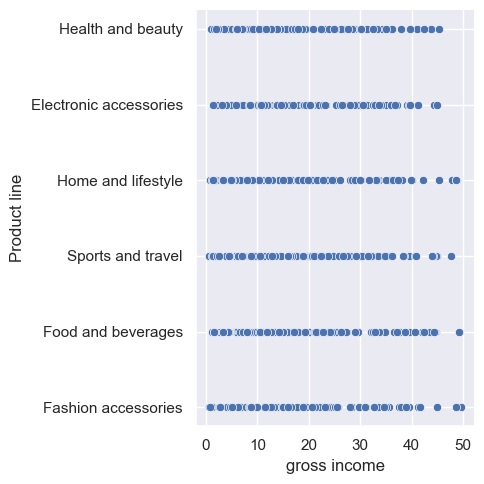

In [36]:
sns.relplot(y = 'Product line', x = 'gross income', data=sales , palette= 'Set2')

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\498733853.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y = 'Product line', x = 'Rating', data=sales , palette='Set1')


<Axes: xlabel='Rating', ylabel='Product line'>

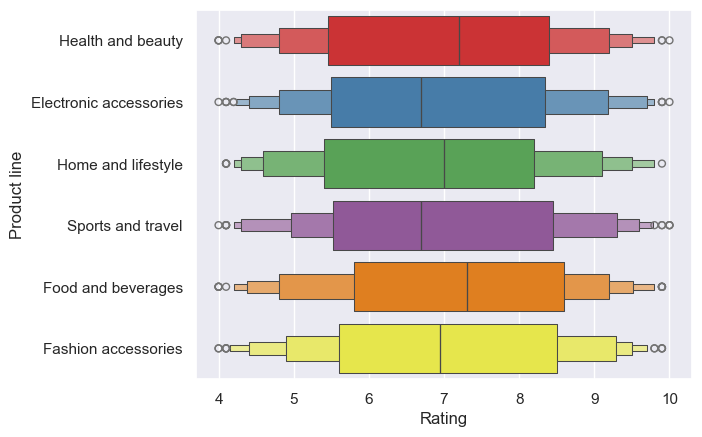

In [38]:
sns.boxenplot(y = 'Product line', x = 'Rating', data=sales , palette='Set1')

Food and Beverages have the highest average rating while sports and travel the lowest

Let's see when customers buy certain products in the various branches. 

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\2670908304.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  productCount  = sns.relplot(x="Hour",  y = 'Quantity', col= 'Product line' , row= 'Branch', estimator = None, kind="line", data =sales,palette= 'Set1')


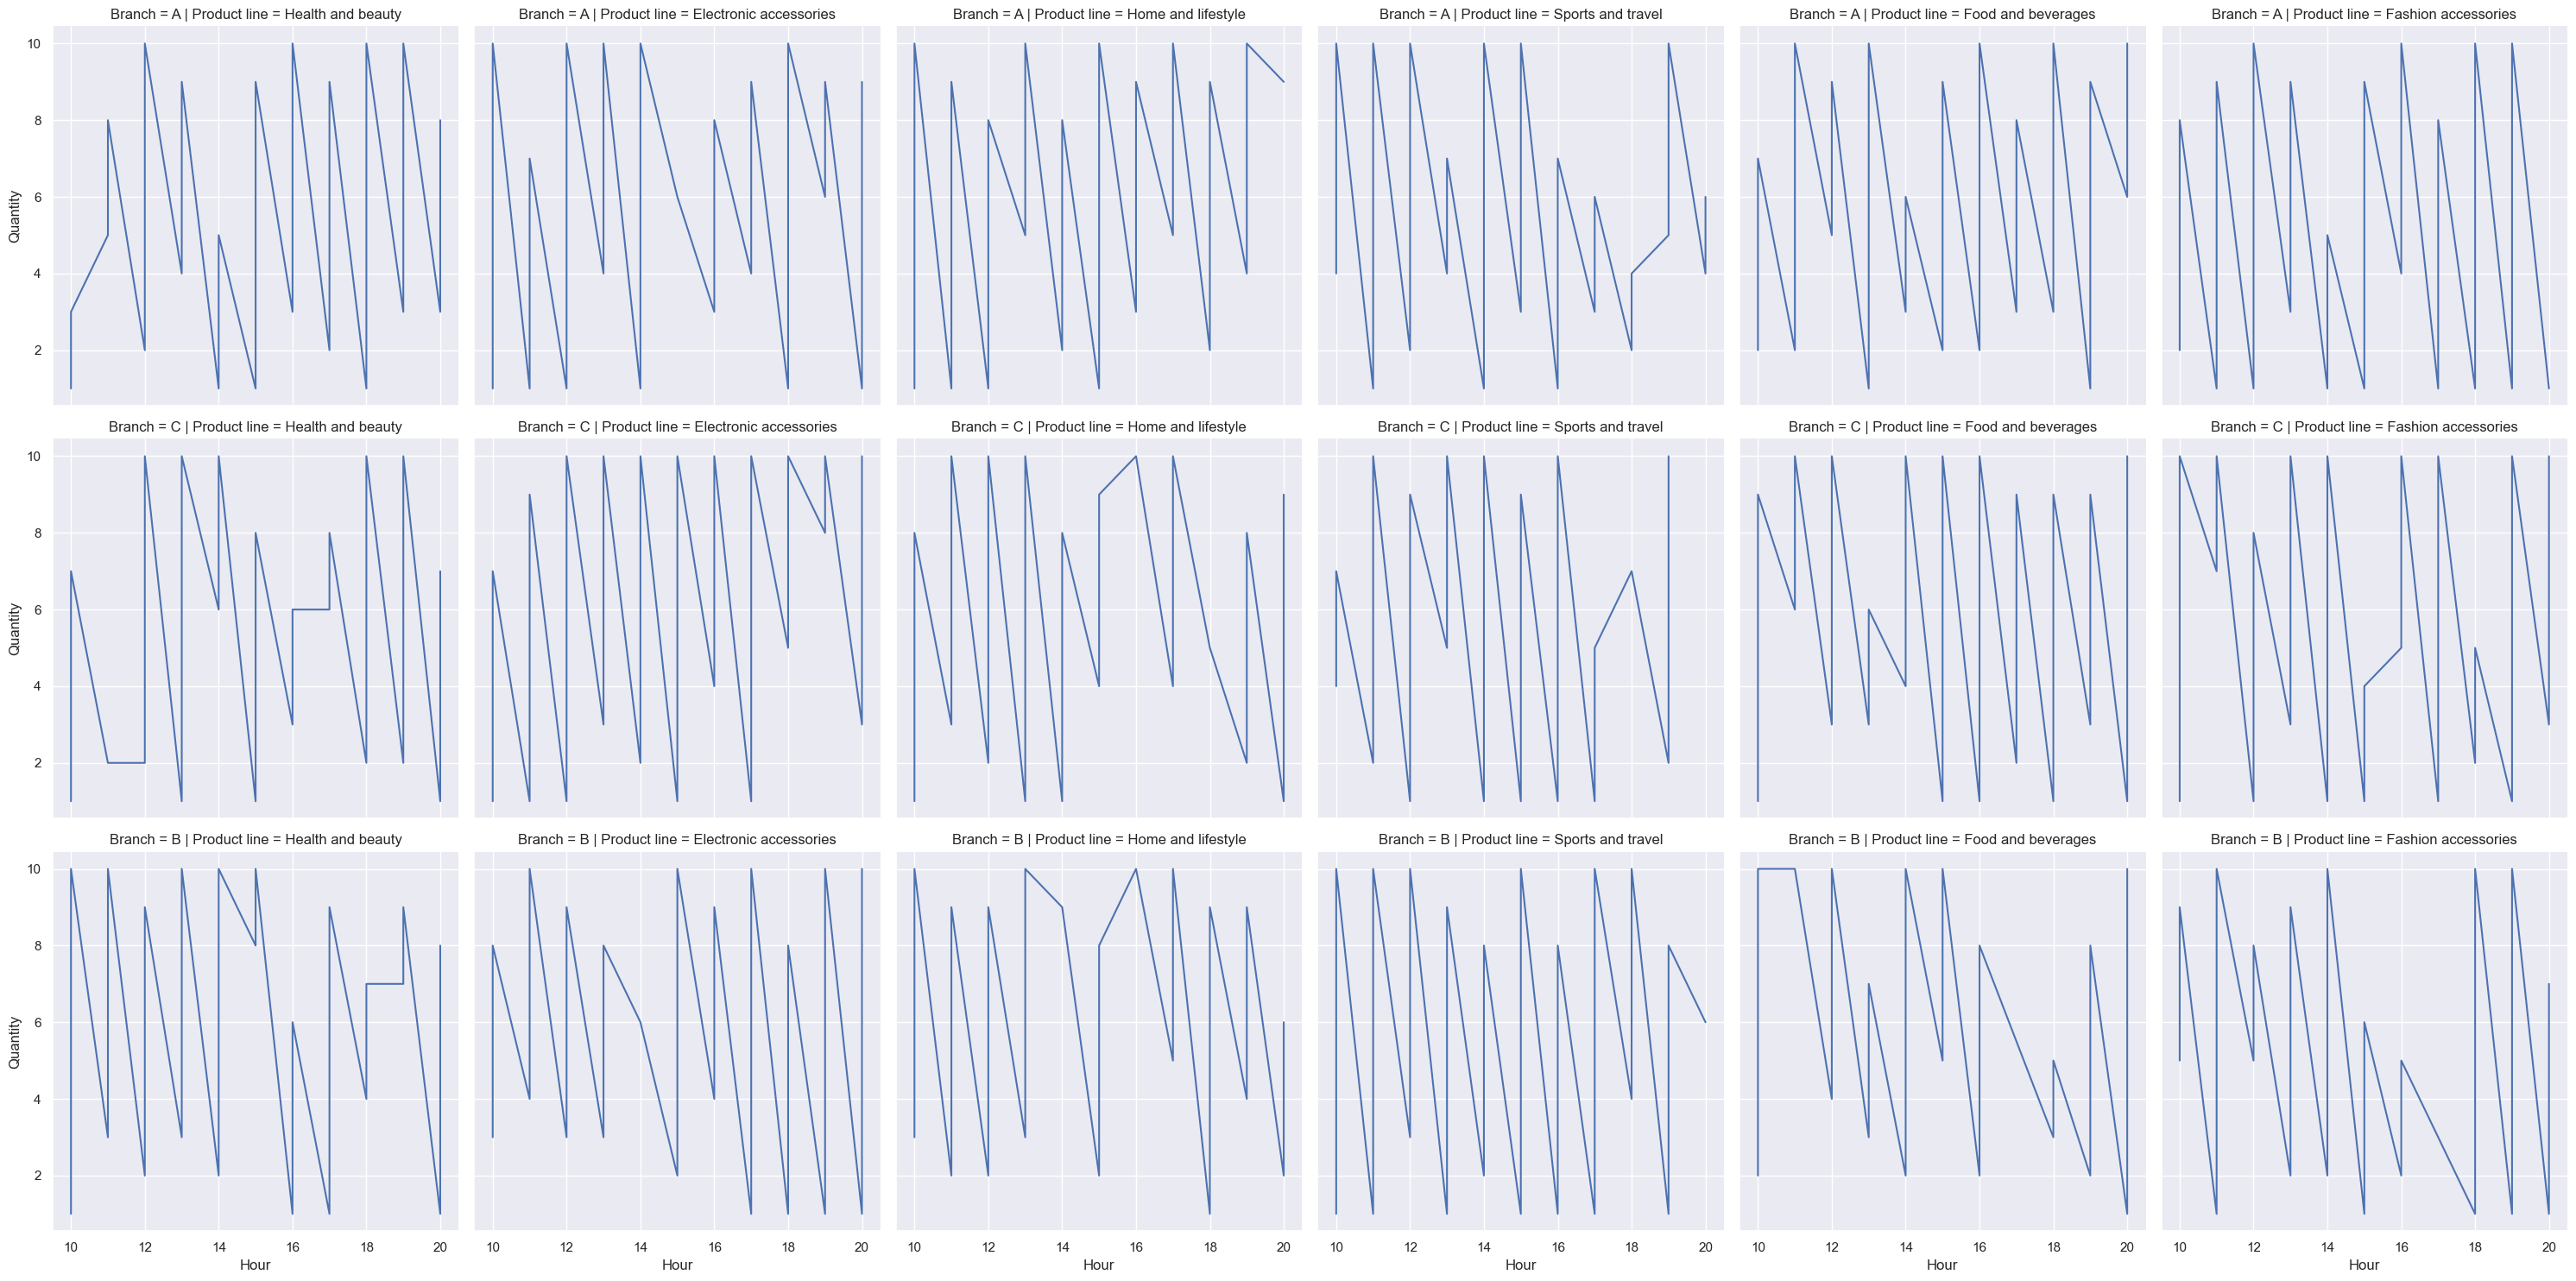

In [39]:
productCount  = sns.relplot(x="Hour",  y = 'Quantity', col= 'Product line' , row= 'Branch', estimator = None, kind="line", data =sales,palette= 'Set1')

From the above plots, we can see that food and beverages sales usually high in all three branches at evening especially around 19:00 

# Payment Channel

Let see how customers make payment in this business

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\1895829077.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Payment", data =sales , palette= 'Set3')


Text(0.5, 1.0, 'Payment Channel')

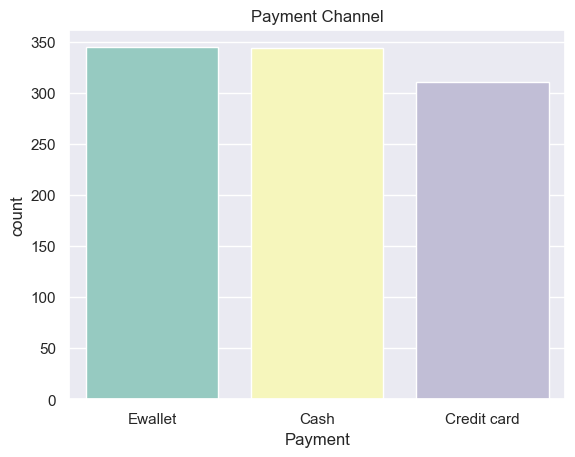

In [41]:
sns.countplot(x="Payment", data =sales , palette= 'Set3')
plt.title("Payment Channel") 

Most of the customers pay through the Ewallet and Cash Payment while under 40 percent of them pay with their credit card. We would also like to see this payment type distribution across all the branches

Text(0.5, 1.0, 'Payment Channel by Branch')

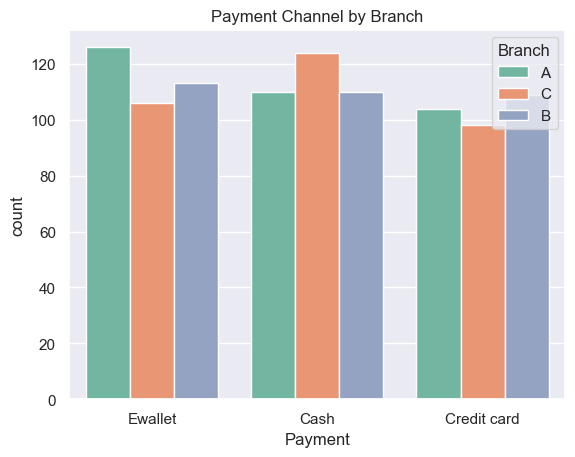

In [43]:
sns.countplot(x="Payment", hue = "Branch", data =sales , palette= 'Set2')
plt.title("Payment Channel by Branch") 

# Customer Analysis

From inspection, there are two types of customers. Members and Normal. Let's see how many they are and where they are 

In [34]:
sales['Customer type'].nunique()

2

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\1328785259.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Customer type", data =sales, palette= 'Set2')


Text(0.5, 1.0, 'Customer Type')

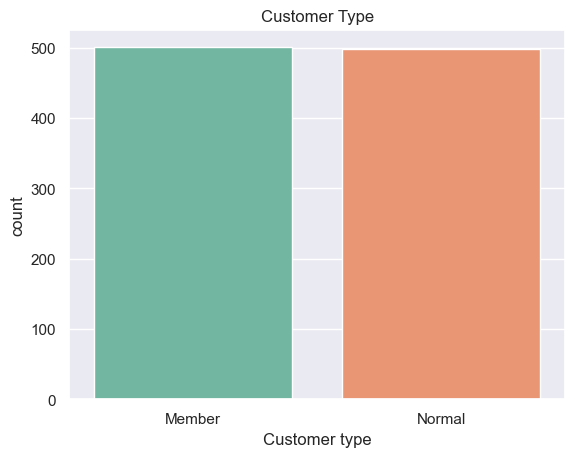

In [44]:
sns.countplot(x="Customer type", data =sales, palette= 'Set2')
plt.title("Customer Type") 

Text(0.5, 1.0, 'Customer Type by Branch')

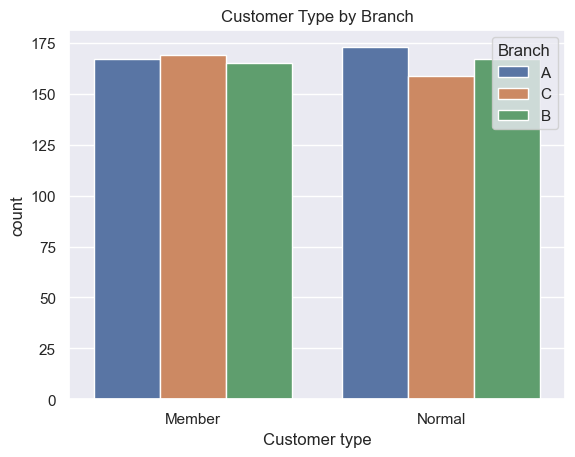

In [45]:
sns.countplot(x="Customer type", hue = "Branch", data =sales).set_title("Customer Type by Branch") 

## Does customer type influences the sales 

In [37]:
sales.groupby(['Customer type']).agg({'Total': 'sum'})

,Total
Customer type,
Member,164223.444
Normal,158743.305


C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\586302882.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Customer type", y="Total", estimator = sum, data=sales, palette= 'Set2')


<Axes: xlabel='Customer type', ylabel='Total'>

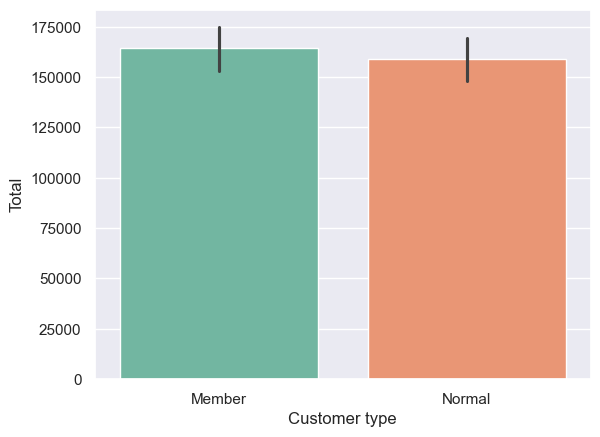

In [46]:
sns.barplot(x="Customer type", y="Total", estimator = sum, data=sales, palette= 'Set2')

Do the customer type influence customer rating? Let's find out 

Text(0.5, 1.0, 'Customer Type')

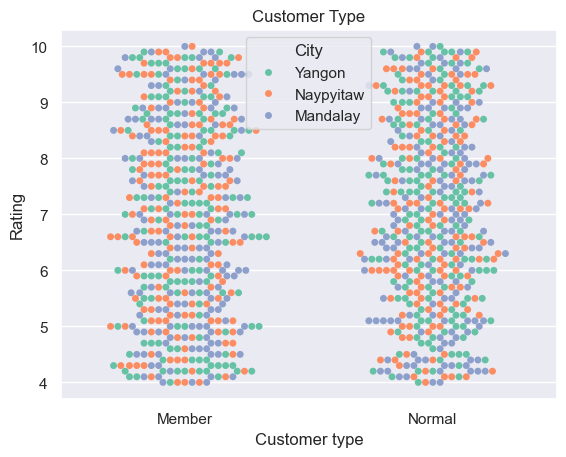

In [47]:
sns.swarmplot(x="Customer type",  y = "Rating",  hue = "City", data =sales , palette= 'Set2')
plt.title("Customer Type") 

With the use of google search, I was able to get the longitude and latitude of each cities. We can 

In [54]:
long = {"Yangon": 16.8661, "Naypyitaw": 19.7633, "Mandalay": 21.9588 }
lat = {"Yangon": 96.1951, "Naypyitaw": 96.0785, "Mandalay": 96.0891 }
for set in sales:
    sales['long'] = sales['City'].map(long)
    sales['lat'] = sales['City'].map(lat)

Text(0.5, 1.0, 'Customer Type')

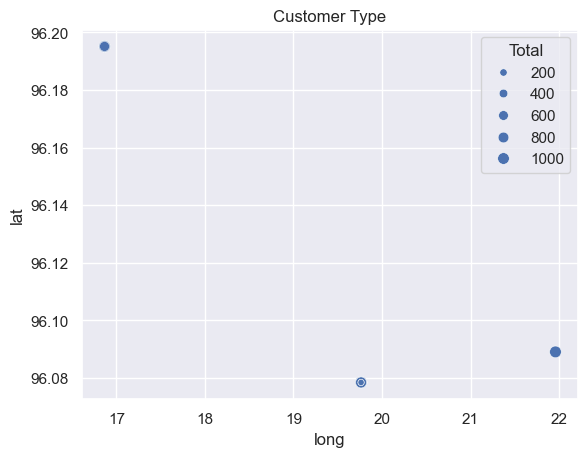

In [56]:
sns.scatterplot(x="long",  y = "lat",size = "Total", data =sales, legend = "brief")
plt.title("Customer Type") 

C:\Users\rhiab\AppData\Local\Temp\ipykernel_12304\759029457.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(x="Total",  y = "Quantity", data =sales , palette='Set2')


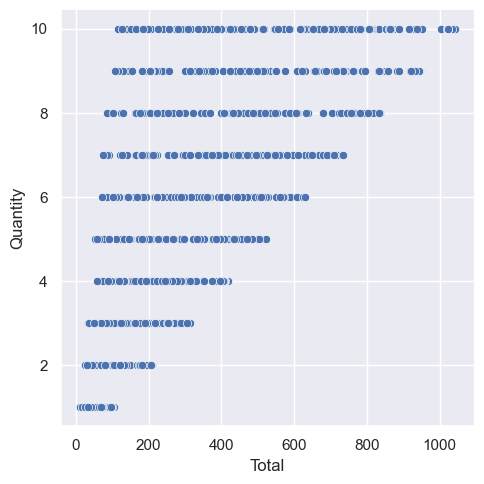

In [57]:
sns.relplot(x="Total",  y = "Quantity", data =sales , palette='Set2')